In [14]:
#This project aims to perform exploratory data analysis on the Netflix dataset to identify trends and generate insights about content distribution, release patterns, and differences between movies and TV shows. It also incorporates a basic predictive model to classify content and includes an interactive feature to retrieve movie details based on user input. The analysis helps in understanding Netflix's content strategy and concludes with key findings.


In [15]:
 #The dataset used in this project is the Netflix Titles dataset, which contains information about movies and TV shows available on Netflix. The dataset was collected in CSV format and stored locally for analysis.

<class 'pandas.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   str    
 1   title                 5849 non-null   str    
 2   type                  5850 non-null   str    
 3   description           5832 non-null   str    
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   str    
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   str    
 8   production_countries  5850 non-null   str    
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   str    
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(2), str(8)


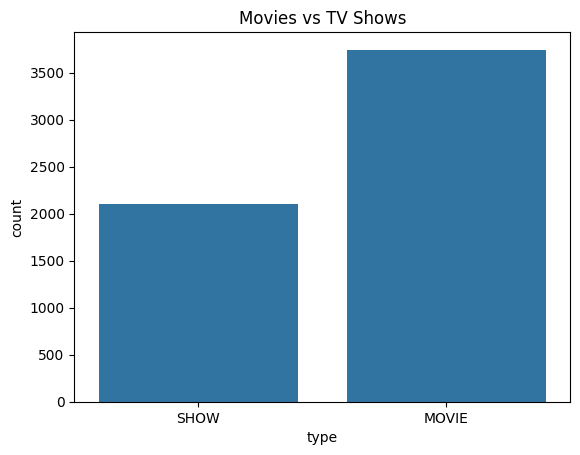

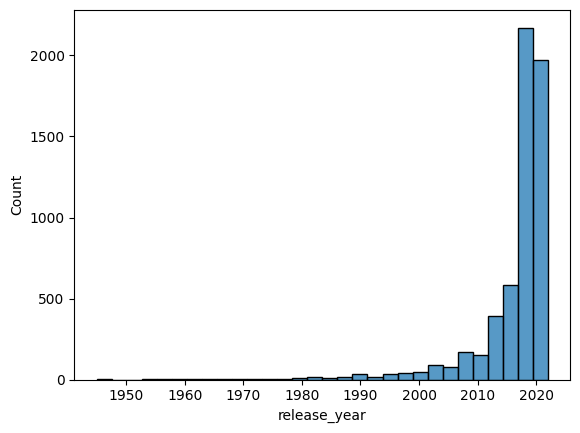

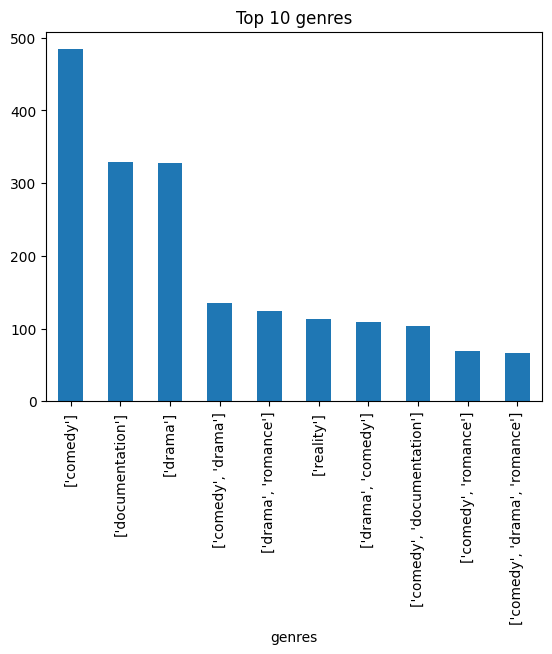

Accuracy: 0.9094017094017094
The content has high rating.


c:\Users\Madhumitha Baskar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [6]:
#Data cleaning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
df = pd.read_csv('titles.csv')
#Method to get the details about the dataset
df.columns
df.head()
df.info()
#Method to find the null values
df.isnull().sum()
#Two methods to handle missing values
df['seasons'] = df['seasons'].fillna(0)
df.isnull().sum()
df.drop('age_certification', axis=1, inplace=True)
df.isnull().sum()
df['imdb_id'] = df['imdb_id'].fillna("Unknown")
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].mean())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].mean())
df['description'] = df['description'].fillna("No description available")
df['title'] = df['title'].fillna("Unknown Title")
df.isnull().sum()
#The dataset was cleaned by handling missing values using appropriate methods such as filling with mean values for numerical columns and default values for categorical columns. Unnecessary columns were removed, and the dataset was checked for duplicates and corrected data types to ensure consistency and accuracy.
#Exploratory Data Analysis
df['type'].value_counts()
#Here we use the value_counts in order to find frequency of the particular value in the dataset.Here Movies and TV shows are mentioned as values.
df['release_year'].value_counts().head(5)
#Here by analyzing the value counts of the release year in the dataset tells about at which year Movies/TVshows released have the higher rate.
#By looking into the dataset we can say that the year 2019 has the highest nnumber releases,this is called as trends and giving what is the reason behind that is called as insights.
df['release_year'].value_counts().tail(5)
df.groupby('type').size()
df.groupby(['release_year','type']).size().unstack()
df['genres'].value_counts().head(5)
df.groupby(['release_year','genres']).size().unstack()
df['imdb_score'].describe()
#Data Visualization
sns.countplot(x='type',data=df)
plt.title("Movies vs TV Shows")
plt.show()
sns.histplot(df['release_year'],bins=30)
plt.show()
df['genres'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 genres")
plt.show()

#Various visualizations were created to better understand the dataset, including distribution of content types, release trends, genre popularity, and ratings distribution. These visualizations help in identifying patterns and making the analysis more intuitive.
#Data Transformation
#Data transformation is used to convert the data into the meaningful one from the exixsting data.
df['release_year'] = df['release_year']//10*10
df.head()
#Here the release_year is transformed into decade
df['high_rating'] = df['imdb_score'].apply(lambda x: 1 if x>= 8 else 0)
df.head(5)
#Analysis
#From the analysis we can say that Netflix has the higher rate of movies compared to Tv shows and in the year 2020 has the higher rate releases and the genre that is liked by the audience is comedy rather than crime,romantic etc..
#Predictive Modeling
x = df[['release_year', 'runtime', 'imdb_votes', 'tmdb_score']]
y = df['high_rating']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)
x_train.shape
#We use the logistic regression to train the model for classification
model = LogisticRegression()
model.fit(x_train,y_train)
#Accuracy of the model prediction
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
#getting the input from the user
user_input = np.array([[1994,243,50000,9.7]])
prediction = model.predict(user_input)
if prediction[0] == 1:
    print("The content has high rating.")
else:
    print("The content does not have a high rating.")
                                                 
